# Crypto multi-horizon trend

This project effectively serves as an extension of crypto_momentum. Instead of the 30d lookback there, the trend signal is averaged over several lookback periods and positions are scaled by volatility.

### Imports

In [29]:
import sys, importlib
from pathlib import Path
import numpy as np
import pandas as pd
from IPython.display import display

PROJECT = next(p for p in (Path.cwd().resolve(), *Path.cwd().resolve().parents) if (p / "src/trend_data.py").is_file())
PORTFOLIO = PROJECT.parent
SIGNAL_FACTORY = PORTFOLIO.parents[1] / "signal_factory"
RAW = PROJECT / "data/raw"

for path in (SIGNAL_FACTORY, PROJECT / "src"):
    sys.path.insert(0, str(path))
import signal_factory as sf
import trend_data

SYMBOLS = ["BTC-GBP", "ETH-GBP"]

def period_return(returns, start, end):
    window = returns[(returns.index >= pd.Timestamp(start, tz="UTC")) & (returns.index < pd.Timestamp(end, tz="UTC"))]
    return (1 + window).prod() - 1

## Execution

Coinbase Exchange daily candles for BTC-GBP and ETH-GBP from 01/01/2019. This is the same structure as in crypto_cross_sectional, where beginning at 00:05, execution happens at the first minute at which both BTC and ETH have a completed, positive volume candle which is no older than 5min.


In [ ]:
DATA_START = "2019-01-01"
DATA_END = "2026-09-01"
prices = trend_data.load_daily_history(SYMBOLS, DATA_START, DATA_END, RAW, allow_download=True)
display(trend_data.audit_daily(prices, SYMBOLS, DATA_START, DATA_END))



,rows,missing_days,nonpositive_or_nonfinite,zero_volume_days
symbol,,,,
BTC-GBP,2800,0,0,0
ETH-GBP,2800,0,0,0


In [31]:
panel = trend_data.to_factory_panel(prices)
schedule = sf.weekly_schedule(panel)
schedule = schedule[schedule < pd.Timestamp(DATA_END, tz="UTC")]

minutes = trend_data.load_monday_minutes(SYMBOLS, schedule, RAW, allow_download=True)
fills = trend_data.minute_fills(minutes, schedule, SYMBOLS)
delay = (fills["execution_at"] - fills.index - pd.Timedelta(minutes=5)).dt.total_seconds() / 60
display(pd.Series({"decisions": len(fills), "unresolved": int(fills["status"].ne("ready").sum()),
                   "delayed past 00:05": int(delay.gt(0).sum()), "latest delay (min)": delay.max()}))

decisions             400.0
unresolved              0.0
delayed past 00:05     18.0
latest delay (min)     12.0
dtype: float64

## Baseline: 30d momentum executed within the hour

Now rerun the 30d momentum approach from crypto_momentum, but execution is changed to occur before 01:00 UTC Monday. This is the approach we aim to beat averaging lookbacks and using volatility weighting

In [ ]:
returns = sf.daily_returns(sf.pivot_closes(panel))
ready = fills.index[fills["status"].eq("ready")]
baseline_schedule = schedule[schedule.isin(ready)]

baseline_targets = sf.build_targets("trend_absolute_30d", panel, baseline_schedule, {"lookback_days": 30})
executions = trend_data.executions_from_fills(baseline_schedule, fills, prices, SYMBOLS)
baseline = sf.run_portfolio(baseline_targets, returns, "pessimistic", cash_rate=0.0, executions=executions)
next_open = sf.run_portfolio(baseline_targets.iloc[:-1], returns, "pessimistic", cash_rate=0.0,
                             executions=trend_data.executions_next_open(baseline_schedule[:-1], prices, SYMBOLS))

periods = {"2021-2023": ("2021-01-01", "2024-01-01"), "2024-2025": ("2024-01-01", "2026-01-01"),
           "01/2026-09/2026": ("2026-01-01", DATA_END)}
pd.DataFrame({name: {"within the hour": period_return(baseline["net_return"], *window), "next daily open": period_return(next_open["net_return"], *window)}
              for name, window in periods.items()}).style.format("{:.2%}")

,2021-2023,2024-2025,2026 to date
within the hour,456.09%,99.64%,3.54%
next daily open,417.31%,96.50%,0.72%


## Development sweep

Now sweep across different parameters (18 distinct configurations). The sweep covers 01/07/2019 to 31/12/2023 only, and nothing is selected here.

In [33]:
import trend_research
importlib.reload(trend_research)

protocol = trend_research.load_protocol(PROJECT / "research/protocol_v1.json")
display(pd.Series(trend_research.check_saved_data(protocol, RAW), name="matches freeze"))

frozen_data = protocol["data"]
prices = trend_data.load_daily_history(SYMBOLS, frozen_data["daily_start"], frozen_data["daily_end_exclusive"], RAW)
panel = trend_data.to_factory_panel(prices)
returns = sf.daily_returns(sf.pivot_closes(panel))

evaluation_end = pd.Timestamp(protocol["periods"]["evaluation_end_exclusive"], tz="UTC")
schedule = sf.weekly_schedule(panel)
schedule = schedule[schedule < evaluation_end]
fills = trend_data.minute_fills(trend_data.load_monday_minutes(SYMBOLS, schedule, RAW), schedule, SYMBOLS)
executions = trend_data.executions_from_fills(schedule, fills, prices, SYMBOLS)

display(trend_research.sweep_configurations(protocol))

daily_files      True
daily_sha256     True
minute_files     True
minute_sha256    True
Name: matches freeze, dtype: bool

,lookbacks,target_volatility,vol_cap,no_trade_band,vol_window_days
C01,"(7, 14, 30, 60, 90, 180)",0.4,40%,0.0,30
C02,"(7, 14, 30, 60, 90, 180)",0.4,40%,0.1,30
C03,"(7, 14, 30, 60, 90, 180)",0.6,60%,0.0,30
C04,"(7, 14, 30, 60, 90, 180)",0.6,60%,0.1,30
C05,"(7, 14, 30, 60, 90, 180)",10.0,none,0.0,30
C06,"(7, 14, 30, 60, 90, 180)",10.0,none,0.1,30
C07,"(14, 30, 60, 90)",0.4,40%,0.0,30
C08,"(14, 30, 60, 90)",0.4,40%,0.1,30
C09,"(14, 30, 60, 90)",0.6,60%,0.0,30
C10,"(14, 30, 60, 90)",0.6,60%,0.1,30


In [34]:
development = trend_research.development_sweep(protocol, panel, schedule, returns, executions)
development.style.format({"total_return": "{:.1%}", "cagr": "{:.1%}", "volatility": "{:.1%}", "sharpe": "{:.3f}",
                          "max_drawdown": "{:.1%}", "annual_turnover": "{:.2f}", "average_cash": "{:.1%}",
                          "weeks_traded": "{:.0f}", "no_trade_band": "{:.0%}"})

,lookbacks,vol_cap,no_trade_band,total_return,cagr,volatility,sharpe,max_drawdown,annual_turnover,average_cash,weeks_traded
C01,"7,14,30,60,90,180",40%,0%,212.6%,28.8%,26.6%,1.084,-32.7%,7.16,63.2%,230
C02,"7,14,30,60,90,180",40%,10%,202.4%,27.8%,26.4%,1.064,-30.2%,5.33,63.8%,218
C03,"7,14,30,60,90,180",60%,0%,326.1%,37.9%,35.9%,1.076,-40.6%,8.81,51.7%,230
C04,"7,14,30,60,90,180",60%,10%,371.2%,41.1%,36.6%,1.124,-37.0%,7.02,51.6%,221
C05,"7,14,30,60,90,180",none,0%,450.4%,46.0%,45.7%,1.058,-45.2%,9.91,43.2%,230
C06,"7,14,30,60,90,180",none,10%,436.3%,45.2%,46.5%,1.037,-46.8%,7.81,43.2%,222
C07,"14,30,60,90",40%,0%,229.0%,30.2%,27.5%,1.099,-33.5%,6.96,63.8%,220
C08,"14,30,60,90",40%,10%,208.4%,28.4%,28.4%,1.022,-31.3%,5.93,63.9%,214
C09,"14,30,60,90",60%,0%,357.0%,40.1%,37.1%,1.094,-41.3%,8.43,52.3%,220
C10,"14,30,60,90",60%,10%,427.4%,44.6%,37.1%,1.181,-38.5%,7.67,53.0%,217


See each method is noticeably worse than the 30d momentum, but this is somewhat expected as that rule was chosen on this development period.

## Annual selection

Each config runs continuously, begining on 01/07/2019. Each January (2021 onwards), the configuration with the highest net Sharpe over all development data to that point is selected until the following January. Lower turnover is the tie-breaker. 2021-2023 results act as a development check.

In [35]:
runs = trend_research.run_all_configurations(protocol, panel, schedule, returns, executions)
choices = trend_research.select_annual(protocol, runs)
choices.join(trend_research.sweep_configurations(protocol)[["lookbacks", "vol_cap", "no_trade_band"]], on="chosen")

,chosen,training_end,training_sharpe,runner_up,lookbacks,vol_cap,no_trade_band
year,,,,,,,
2021,C07,2021-01-01,1.594948,C01,"(14, 30, 60, 90)",40%,0.0
2022,C10,2022-01-01,1.698017,C07,"(14, 30, 60, 90)",60%,0.1
2023,C10,2023-01-01,1.159548,C04,"(14, 30, 60, 90)",60%,0.1
2024,C10,2024-01-01,1.181040,C04,"(14, 30, 60, 90)",60%,0.1
2025,C13,2025-01-01,1.259289,C10,"(30, 60, 90, 180)",40%,0.0
2026,C10,2026-01-01,1.176933,C07,"(14, 30, 60, 90)",60%,0.1


In [36]:
portfolios = trend_research.evaluation_portfolios(protocol, runs, choices, panel, schedule, returns, executions)
trend_research.results_table(portfolios, "2021-01-01", "2024-01-01").style.format({"total_return": "{:.1%}", "cagr": "{:.1%}", "volatility": "{:.1%}", "sharpe": "{:.3f}", "max_drawdown": "{:.1%}", "annual_turnover": "{:.2f}", "average_cash": "{:.1%}", "weeks_traded": "{:.0f}"}, na_rep="-")

,total_return,cagr,volatility,sharpe,max_drawdown,annual_turnover,average_cash,weeks_traded
Multi-horizon trend,57.9%,16.5%,29.3%,0.668,-36.1%,7.92,59.4%,141
30d momentum,456.1%,77.2%,48.4%,1.425,-39.4%,10.81,49.0%,105
25/25/50 mix,89.3%,23.7%,34.5%,0.790,-45.8%,1.08,50.0%,156
50/50 buy-and-hold,-,-,-,-,-,-,-,-


## Evaluation: 01/2024 to 09/2026

Use transaction fees of 25bp round trip analogous to other projects. Cash earns no interest. Dates were already tested on during crypto_momentum, but multi-horizon hadn't been.

In [37]:
evaluation_start = protocol["periods"]["evaluation_start"]
evaluation_end = protocol["periods"]["evaluation_end_exclusive"]
trend_research.results_table(portfolios, evaluation_start, evaluation_end).style.format({"total_return": "{:.1%}", "cagr": "{:.1%}", "volatility": "{:.1%}", "sharpe": "{:.3f}", "max_drawdown": "{:.1%}", "annual_turnover": "{:.2f}", "average_cash": "{:.1%}", "weeks_traded": "{:.0f}"}, na_rep="-")

,total_return,cagr,volatility,sharpe,max_drawdown,annual_turnover,average_cash,weeks_traded
Multi-horizon trend,85.2%,25.3%,28.4%,0.937,-26.2%,7.52,51.4%,136
30d momentum,132.2%,36.2%,32.5%,1.110,-31.9%,12.11,48.3%,105
25/25/50 mix,37.8%,12.5%,26.8%,0.572,-34.9%,0.87,50.0%,143
50/50 buy-and-hold,53.9%,17.1%,51.1%,0.563,-57.6%,0.37,0.0%,1


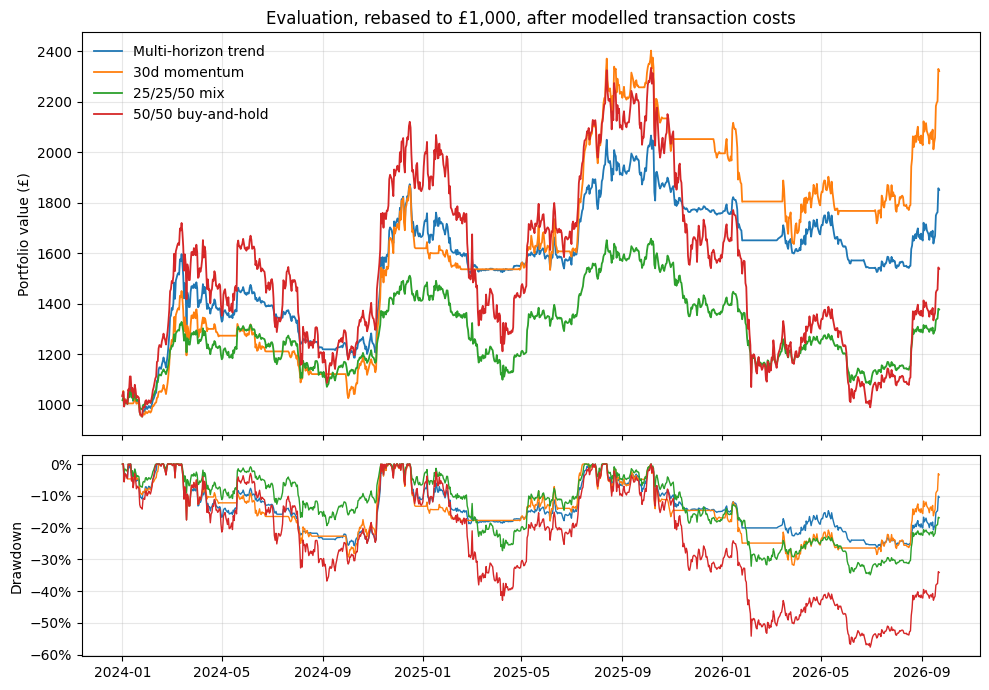

In [38]:
import trend_plotting
importlib.reload(trend_plotting)
fig = trend_plotting.plot_evaluation_equity(portfolios, evaluation_start, evaluation_end, PROJECT / "figures/evaluation_equity.png")

In [39]:
trend_research.yearly_returns(portfolios, "2021-01-01", evaluation_end).style.format("{:.1%}", na_rep="-")

,Multi-horizon trend,30d momentum,25/25/50 mix,50/50 buy-and-hold
timestamp,,,,
2021,46.6%,265.8%,91.9%,-
2022,-25.7%,-20.4%,-33.9%,-
2023,44.9%,91.0%,49.3%,-
2024,66.7%,62.0%,41.4%,85.5%
2025,5.5%,23.2%,-3.4%,-14.7%
2026,5.2%,16.3%,0.9%,-2.7%


See pretty clearly that over time, 30d momentum outperforms all other approaches.

### Significance testing

Sharpe ratio of the multi-horizon rule minus Sharpe of 30d momentum over the evaluation period. For a statistical edge, require an a lower interval bound which is positive.

In [40]:
trend_research.sharpe_difference_tests(protocol, portfolios).style.format({"estimate": "{:+.3f}", "ci_lower": "{:+.3f}", "ci_upper": "{:+.3f}"})

,estimate,ci_lower,ci_upper,resamples,primary
block_days,,,,,
28,-0.174,-0.658,+0.313,10000,True
14,-0.174,-0.669,+0.316,10000,False
56,-0.174,-0.664,+0.282,10000,False


See the insignificance, which was obvious reading through the data.

### Sensitivities

Run same choices with (pessimistic) transaction costs to check stability to transaction costs

In [41]:
scenarios = {"primary": ("pessimistic", 0.0), "stress costs": ("stress", 0.0), "cash at 3.75%": ("pessimistic", 0.0375)}
rows = {}
for label, (cost_mode, cash_rate) in scenarios.items():
    scenario = trend_research.evaluation_portfolios(protocol, runs, choices, panel, schedule, returns, executions, cost_mode=cost_mode, cash_rate=cash_rate)
    table = trend_research.results_table(scenario, evaluation_start, evaluation_end)
    for name in ("Multi-horizon trend", "30d momentum"):
        rows[(label, name)] = table.loc[name, ["total_return", "sharpe", "max_drawdown"]]
pd.DataFrame(rows).T.style.format({"total_return": "{:.1%}", "sharpe": "{:.3f}", "max_drawdown": "{:.1%}"})

## Conclusion

Averaging lookbacks periods, and scaling using volatility did reduce drawdowns, but at the cost of too much return. This approach had generally worse Sharpe, although the significance test was insignificant. The evidence does not support using this approach instead of the currently chosen 30d momentum approach, now executed within the hour instead of the following day.